# MakerWorld Contest Theme & Category Demand Study
**Author:** Flavio Akira Tikaishi · Business Intelligence / Business Analyst portfolio

**Business question:** Which contest themes attract the most makers and the most attention on MakerWorld, and which contests were the best and worst performers?

**Data:** 158 design contests (Oct 2023 – Sep 2026) collected from the public MakerWorld contests page and each contest's detail page (entries, participants, views, dates, host, prize list, winners).

**Steps:** 1) Load & clean → 2) Categorize themes → 3) Feature engineering → 4) Composite score & tiers → 5) Category / host / seasonality analysis → 6) Best & worst contests → 7) Recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import json

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
SNAPSHOT_DATE = pd.Timestamp("2026-09-25")

cards = pd.read_csv("data/contest_cards.csv", sep=";")
details = pd.read_csv("data/contest_details.csv", sep="|")
df = cards.merge(details, on="contest_id", how="left")
df["start_date"] = pd.to_datetime(df["start_date"])
df["end_date"] = pd.to_datetime(df["end_date"])
print(df.shape)
df.head()

(158, 18)


,contest_id,host_code,contest_name,models,participants,views,start_date,end_date,awards,prize_usd,hardware_awards,winners,winner_likes,winner_downloads,first_prize_title,first_prize_creator,first_prize_likes,avg_likes_listed
0,1,O,Halloween,915,453,162327,2023-10-06,2023-10-31,18,1500,0,18,24487,45365,Haunted Hearse - Print-in-Place Fold,Whopper Printing,1746.0,162
1,2,O,Fidget Toys,398,286,396362,2023-11-05,2023-11-26,18,1800,0,18,96739,482181,Double Action OTF Knife/Comb,Asdfgasdfg,5306.0,482
2,3,O,Christmas Decoration,1582,681,238277,2023-11-12,2023-12-03,23,1400,0,23,45175,103783,Arctic Glow Christmas Lantern LED la,Kardes.Design,5946.0,118
3,4,O,Make My Sign,889,469,141111,2023-11-20,2023-12-10,13,1000,0,13,7547,19665,Customizable Prize Wheel,Kit Crafters,1240.0,32
4,5,O,Flying Objects,252,212,206655,2023-11-26,2023-12-17,13,1000,0,13,50262,154475,Batwing,Wcad00,1588.0,533


## 1. Data cleaning & feature engineering
* `host_type`: Official (MakerWorld), Master Challenge (MakerWorld, advanced engineering brief), Creator-hosted.
* `status`: contests still running on the snapshot date are excluded from rankings (their numbers are incomplete).
* Derived KPIs: duration, **models per day** (submission velocity), **models per participant** (depth), **views per model** (attention per entry).

In [2]:
host_map = {"O": "Official", "M": "Master Challenge", "C": "Creator-hosted"}
df["host_type"] = df["host_code"].map(host_map)
df["status"] = np.where(df["end_date"] < SNAPSHOT_DATE, "Finished", "Running")
df["duration_days"] = (df["end_date"] - df["start_date"]).dt.days + 1
df["models_per_day"] = df["models"] / df["duration_days"]
df["models_per_participant"] = df["models"] / df["participants"]
df["views_per_model"] = df["views"] / df["models"]
df["year"] = df["start_date"].dt.year
df["start_month"] = df["start_date"].dt.month
df["brand_sponsored"] = df["contest_name"].str.contains(
    "CMF|Corcelain|realme|TRYX|Vortek|Insta360|Power Meets|Wireless Mouse|Photography", case=False)
print(df["status"].value_counts())
print(df["host_type"].value_counts())
print(df[["models", "participants", "views", "duration_days"]].describe().round(0))

status
Finished    150
Running       8
Name: count, dtype: int64
host_type
Official            123
Creator-hosted       20
Master Challenge     15
Name: count, dtype: int64
       models  participants     views  duration_days
count   158.0         158.0     158.0          158.0
mean    835.0         609.0  276536.0           29.0
std    1074.0         588.0  127002.0            8.0
min      40.0          40.0   64711.0           17.0
25%     316.0         302.0  181766.0           24.0
50%     556.0         480.0  264329.0           27.0
75%     910.0         680.0  346826.0           33.0
max    7078.0        3634.0  728215.0           66.0


## 2. Theme taxonomy
Every contest was classified by hand into one of six categories based on its theme brief. Brand-sponsored contests (phones, PC cases, cameras…) are kept inside their natural category and flagged separately.

In [3]:
category_rules = {
    "Seasonal & Holidays": [1,3,9,10,12,17,23,51,60,62,70,73,83,97,113,120,121,127,128,133,134,158,166],
    "Home & Functional": [4,6,7,11,14,18,20,21,26,28,39,42,44,47,53,56,64,65,69,74,76,82,85,88,89,93,94,98,105,106,108,115,118,130,137,142,144,149,156,159],
    "Toys & Games": [2,5,8,15,32,37,45,48,58,66,84,86,90,91,96,104,139,141,145,146,147,150,155,163,165],
    "Art, Décor & Fashion": [13,16,19,24,29,30,33,52,57,61,77,79,92,100,103,107,110,112,117,119,122,125,131,132,136,140,143,154,162],
    "Engineering & Tech": [22,25,27,34,87,38,43,54,55,63,67,72,75,80,99,101,102,109,111,114,116,123,124,126,129,135,151,152,153,157,160,161],
    "Education & Social Good": [31,40,59,68,78,81,95,138,164],
}
cat_lookup = {cid: cat for cat, ids in category_rules.items() for cid in ids}
df["category"] = df["contest_id"].map(cat_lookup)
assert df["category"].notna().all(), df.loc[df["category"].isna(), ["contest_id", "contest_name"]]
print(df["category"].value_counts())

category
Home & Functional          40
Engineering & Tech         32
Art, Décor & Fashion       29
Toys & Games               25
Seasonal & Holidays        23
Education & Social Good     9
Name: count, dtype: int64


## 3. Composite Performance Score & tiers
Only **finished** contests are scored. Each KPI is converted to a percentile rank (0–100) so that very different scales can be combined:

| Component | KPI | Weight | Why |
|---|---|---|---|
| Participation | participants | 40% | How many makers the theme activated |
| Velocity | models per day | 30% | Submission output, fair across contest lengths |
| Reach | views | 30% | Audience attention |

Tiers follow the same logic as the Pokémon study: **S** = top 10%, **A** = next 20%, **B** = middle 40%, **C** = bottom 30%.

In [4]:
fin = df[df["status"] == "Finished"].copy()
weights = {"participants": 0.40, "models_per_day": 0.30, "views": 0.30}
for col in weights:
    fin[f"pct_{col}"] = fin[col].rank(pct=True) * 100
fin["score"] = sum(fin[f"pct_{c}"] * w for c, w in weights.items()).round(1)
q = fin["score"].quantile([0.30, 0.70, 0.90])
fin["tier"] = pd.cut(fin["score"], [-1, q[0.30], q[0.70], q[0.90], 101], labels=["C", "B", "A", "S"])
print("Tier cut-offs:", q.round(1).to_dict())
print(fin["tier"].value_counts().sort_index(ascending=False))

Tier cut-offs: {0.3: 33.7, 0.7: 64.8, 0.9: 84.0}
tier
S    15
A    30
B    59
C    46
Name: count, dtype: int64


## 4. Best and worst contests

In [5]:
cols = ["contest_name", "category", "host_type", "models", "participants", "views", "models_per_day", "score", "tier"]
best = fin.sort_values("score", ascending=False).head(10)[cols]
worst = fin.sort_values("score").head(10)[cols]
print("TOP 10\n", best.round(1).to_string(index=False))
print("\nBOTTOM 10\n", worst.round(1).to_string(index=False))

TOP 10
                            contest_name            category host_type  models  participants  views  models_per_day  score tier
                         Cozy Christmas Seasonal & Holidays  Official    6254          3362 672259           271.9   99.5    S
                          Printmas 2025 Seasonal & Holidays  Official    7078          3634 636726           228.3   99.2    S
                         Halloween 2025 Seasonal & Holidays  Official    5738          3047 728215           212.5   99.1    S
                   2025 Valentine's Day Seasonal & Holidays  Official    4563          2965 580305           169.0   97.6    S
                         Halloween 2024 Seasonal & Holidays  Official    3656          2122 662455            81.2   96.7    S
       Eggs, but not just Eggs (Easter) Seasonal & Holidays  Official    3199          2073 396864           103.2   92.9    S
                         Gardening Tool   Home & Functional  Official    1775          1275 462325     

## 5. Category demand

In [6]:
cat = fin.groupby("category").agg(
    contests=("contest_id", "count"),
    total_models=("models", "sum"),
    median_models=("models", "median"),
    median_participants=("participants", "median"),
    median_views=("views", "median"),
    median_models_per_day=("models_per_day", "median"),
    avg_score=("score", "mean"),
    s_or_a=("tier", lambda t: (t.isin(["S", "A"])).mean() * 100),
    winner_likes_per_winner=("winner_likes", "sum"),
    winners=("winners", "sum"),
).sort_values("avg_score", ascending=False)
cat["share_of_models_%"] = cat["total_models"] / cat["total_models"].sum() * 100
cat["winner_likes_per_winner"] = cat["winner_likes_per_winner"] / cat["winners"]
cat = cat.drop(columns="winners")
print(cat.round(1).to_string())

                         contests  total_models  median_models  median_participants  median_views  median_models_per_day  avg_score  s_or_a  winner_likes_per_winner  share_of_models_%
category                                                                                                                                                                               
Seasonal & Holidays            22         51539         1379.5                949.0      294971.0                   62.2       70.1    63.6                   1433.1               39.6
Education & Social Good         8          6249          683.0                551.5      315206.0                   27.4       60.6    37.5                   1206.4                4.8
Home & Functional              40         28503          624.0                538.5      286135.5                   26.0       55.6    42.5                   1790.0               21.9
Toys & Games                   23         15072          499.0                46

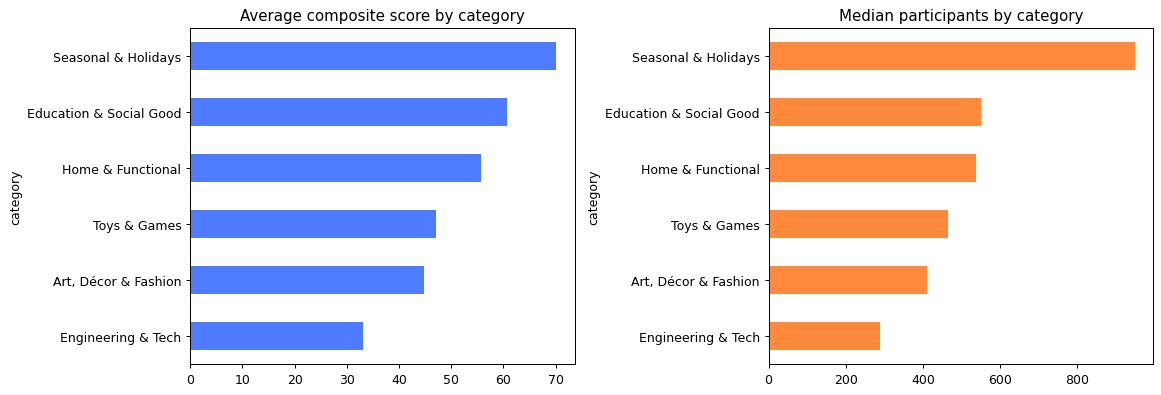

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cat["avg_score"].sort_values().plot.barh(ax=axes[0], color="#4f7cff")
axes[0].set_title("Average composite score by category")
cat["median_participants"].sort_values().plot.barh(ax=axes[1], color="#ff8a3d")
axes[1].set_title("Median participants by category")
plt.tight_layout()
plt.show()

### Reach vs. participation matrix
Median views (x) vs. median participants (y). The top-right quadrant is where themes both attract an audience and activate makers.

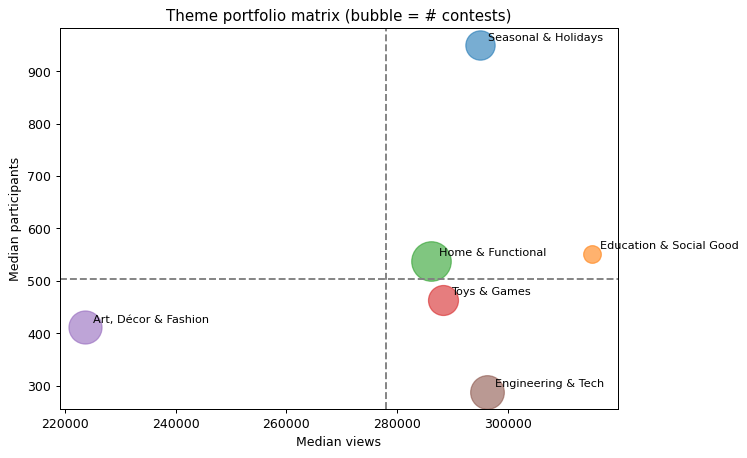

In [8]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for c, r in cat.iterrows():
    ax.scatter(r["median_views"], r["median_participants"], s=r["contests"] * 25, alpha=0.6)
    ax.annotate(c, (r["median_views"], r["median_participants"]), fontsize=9, xytext=(6, 4), textcoords="offset points")
ax.axvline(fin["views"].median(), ls="--", c="grey"); ax.axhline(fin["participants"].median(), ls="--", c="grey")
ax.set_xlabel("Median views"); ax.set_ylabel("Median participants"); ax.set_title("Theme portfolio matrix (bubble = # contests)")
plt.show()

## 6. Host type: Official vs Master Challenge vs Creator-hosted

In [9]:
host = fin.groupby("host_type").agg(
    contests=("contest_id", "count"),
    median_models=("models", "median"),
    median_participants=("participants", "median"),
    median_views=("views", "median"),
    median_duration=("duration_days", "median"),
    avg_score=("score", "mean"),
).sort_values("avg_score", ascending=False)
print(host.round(1).to_string())

                  contests  median_models  median_participants  median_views  median_duration  avg_score
host_type                                                                                               
Official               121          601.0                526.0      283186.0             25.0       53.9
Master Challenge        14          325.0                309.5      300128.5             33.5       36.6
Creator-hosted          15          570.0                408.0      158618.0             34.0       34.6


## 7. Seasonality & the holiday effect
The biggest contests are all holiday themes. How much bigger are they than a normal contest?

In [10]:
holiday_kw = "Halloween|Christmas|Printmas|Valentine|Easter|Eggs"
fin["mega_holiday"] = fin["contest_name"].str.contains(holiday_kw, case=False)
mh = fin.groupby("mega_holiday")[["models", "participants", "views"]].median()
print(mh)
print("Holiday lift (median participants):", round(mh.loc[True, "participants"] / mh.loc[False, "participants"], 1), "x")
print("Share of all submitted models from", fin["mega_holiday"].sum(), "holiday contests:",
      round(fin.loc[fin.mega_holiday, "models"].sum() / fin["models"].sum() * 100, 1), "%")

              models  participants     views
mega_holiday                                
False          546.0         471.5  266772.0
True          3605.5        2098.0  375851.0
Holiday lift (median participants): 4.4 x
Share of all submitted models from 12 holiday contests: 33.7 %


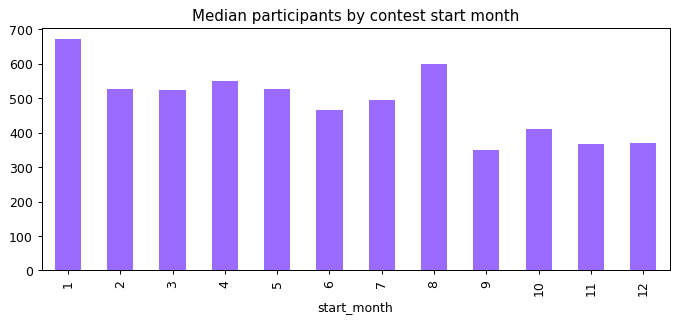

In [11]:
monthly = fin.groupby("start_month")["participants"].median()
monthly.plot.bar(figsize=(9, 3.5), color="#9b6bff", title="Median participants by contest start month")
plt.show()

### Holiday cannibalization
Do regular contests that run alongside a holiday mega-contest (Sep–Dec) attract fewer makers?

In [12]:
reg = fin[~fin["mega_holiday"]].copy()
reg["holiday_season"] = reg["start_month"].isin([9, 10, 11, 12])
cannibal = reg.groupby("holiday_season")[["participants", "models", "score"]].median()
print(cannibal)
print("Regular contests in Sep-Dec get", round((1 - cannibal.loc[True, "participants"] / cannibal.loc[False, "participants"]) * 100, 1), "% fewer participants")

                participants  models  score
holiday_season                             
False                  526.0   588.0   52.9
True                   347.0   365.0   32.8
Regular contests in Sep-Dec get 34.0 % fewer participants


### Brand-sponsored contests

In [13]:
brand = fin.groupby("brand_sponsored")[["participants", "models", "views", "score"]].median()
print(brand)

                 participants  models     views  score
brand_sponsored                                       
False                   523.0   588.0  279817.0   52.0
True                    285.0   267.0  249205.0   30.8


## 8. Trend over time
Contest volume and median participation per year (by start date).

In [14]:
yearly = fin.groupby("year").agg(contests=("contest_id", "count"), median_participants=("participants", "median"),
                                 median_views=("views", "median"), creator_hosted=("host_code", lambda s: (s == "C").sum()))
print(yearly)

      contests  median_participants  median_views  creator_hosted
year                                                             
2023         9                404.0      189592.0               0
2024        54                531.0      291545.0               0
2025        55                455.0      323424.0               1
2026        32                523.5      196577.5              14


## 9. Do bigger prizes buy participation?
Cash-equivalent prize pool (USD gift cards) vs participants, excluding holiday mega-contests.

In [15]:
p = fin[(fin["prize_usd"] > 0) & (~fin["mega_holiday"])]
corr = p[["prize_usd", "participants"]].corr(method="spearman").iloc[0, 1]
print("Spearman correlation prize_usd vs participants:", round(corr, 2), "(n =", len(p), ")")
corr_views_age = fin[["views", "end_date"]].assign(age=(SNAPSHOT_DATE - fin["end_date"]).dt.days)[["views", "age"]].corr(method="spearman").iloc[0, 1]
print("Spearman correlation views vs contest age:", round(corr_views_age, 2))

Spearman correlation prize_usd vs participants: -0.18 (n = 132 )
Spearman correlation views vs contest age: 0.15


## 10. Export for the web report

In [16]:
out = {
    "kpis": {
        "contests": int(len(df)), "finished": int(len(fin)),
        "models": int(df["models"].sum()), "participants": int(df["participants"].sum()),
        "views": int(df["views"].sum()),
    },
    "tier_cutoffs": {k: round(v, 1) for k, v in q.to_dict().items()},
    "category": cat.round(1).reset_index().to_dict(orient="records"),
    "host": host.round(1).reset_index().to_dict(orient="records"),
    "best": fin.sort_values("score", ascending=False).head(10)[cols + ["first_prize_title", "first_prize_creator"]].round(1).to_dict(orient="records"),
    "worst": fin.sort_values("score").head(10)[cols].round(1).to_dict(orient="records"),
    "monthly": {int(k): float(v) for k, v in monthly.items()},
    "yearly": yearly.reset_index().to_dict(orient="records"),
    "holiday": {"lift": round(mh.loc[True, "participants"] / mh.loc[False, "participants"], 1),
                "share_models": round(fin.loc[fin.mega_holiday, "models"].sum() / fin["models"].sum() * 100, 1),
                "n": int(fin["mega_holiday"].sum()), "mega_median": float(mh.loc[True, "participants"])},
    "cannibal": {"in_season": float(cannibal.loc[True, "participants"]), "off_season": float(cannibal.loc[False, "participants"]),
                 "n_in": int(reg["holiday_season"].sum())},
    "brand": {"sponsored": float(brand.loc[True, "participants"]), "not": float(brand.loc[False, "participants"]),
              "sponsored_score": float(brand.loc[True, "score"]), "not_score": float(brand.loc[False, "score"]), "n": int(fin["brand_sponsored"].sum())},
    "prize_corr": round(corr, 2), "views_age_corr": round(corr_views_age, 2),
    "scatter": fin[["contest_name", "category", "views", "participants", "score", "tier"]].to_dict(orient="records"),
    "cat_best_worst": {c: {"best": g.sort_values("score").iloc[-1]["contest_name"], "best_score": float(g["score"].max()),
                           "worst": g.sort_values("score").iloc[0]["contest_name"], "worst_score": float(g["score"].min())}
                       for c, g in fin.groupby("category")},
}
json.dump(out, open("results.json", "w"), default=str, indent=1)
fin.to_csv("data/contests_scored.csv", index=False)
print("saved results.json and data/contests_scored.csv")

saved results.json and data/contests_scored.csv
